In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = os.path.dirname(os.getcwd()) + '/PDAC/sim/HCC_outputs/'

In [3]:
keys = ['c','t','tcd4','mdsc','mac','fib','apc','vas']
counts = {}
for i in range(len(keys)):
    counts[keys[i]] = np.zeros(281)

for i in range(281):
    temp = pd.read_csv(path + 'snapShots/cell_' + str(i) + '.csv',header=0)
    ag_type = temp['Type'].to_numpy()
    for j in range(len(keys)):
        counts[keys[j]][i] = len(ag_type[ag_type==(j+1)])
    
    

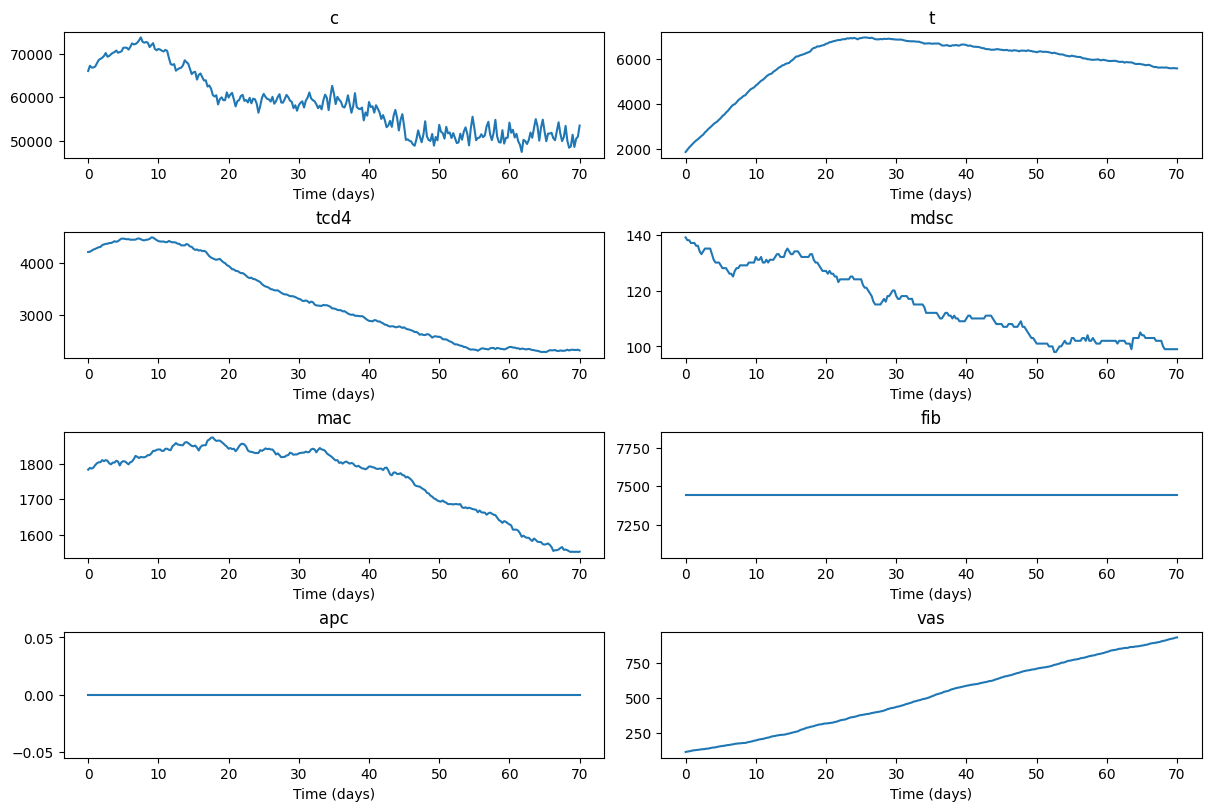

In [4]:
fig,axes = plt.subplots(4,2,figsize=(12,8),layout = 'constrained')
t = np.linspace(0,70,281)
for i,ax in enumerate(axes.reshape(-1)):
    ax.plot(t, counts[keys[i]], label = keys[i])
    ax.set_title(keys[i])
    ax.set_xlabel('Time (days)')

In [5]:
temp = pd.read_csv(path + 'QSP_1771870149.csv',header=0)
columns = [['V_T.C1','V_T.C2'],'V_T.T1',['V_T.T0','V_T.Th'],'V_T.MDSC',['V_T.Mac_M1','V_T.Mac_M2'],['V_T.Fib','V_T.CAF'],['V_T.APC','V_T.mAPC'],'V_T.c_vas']
qsp_counts = {}
for elem in keys:
    qsp_counts[elem] = np.zeros(281)

for i, elem in enumerate(columns):
    data = temp[elem].to_numpy()
    if i == 0 or i == 2 or i == 4 or i == 5 or i == 6:
        data = np.sum(data,axis=1)
    if i == 7:
        data = np.zeros((281,))

    qsp_counts[keys[i]] = data[:]

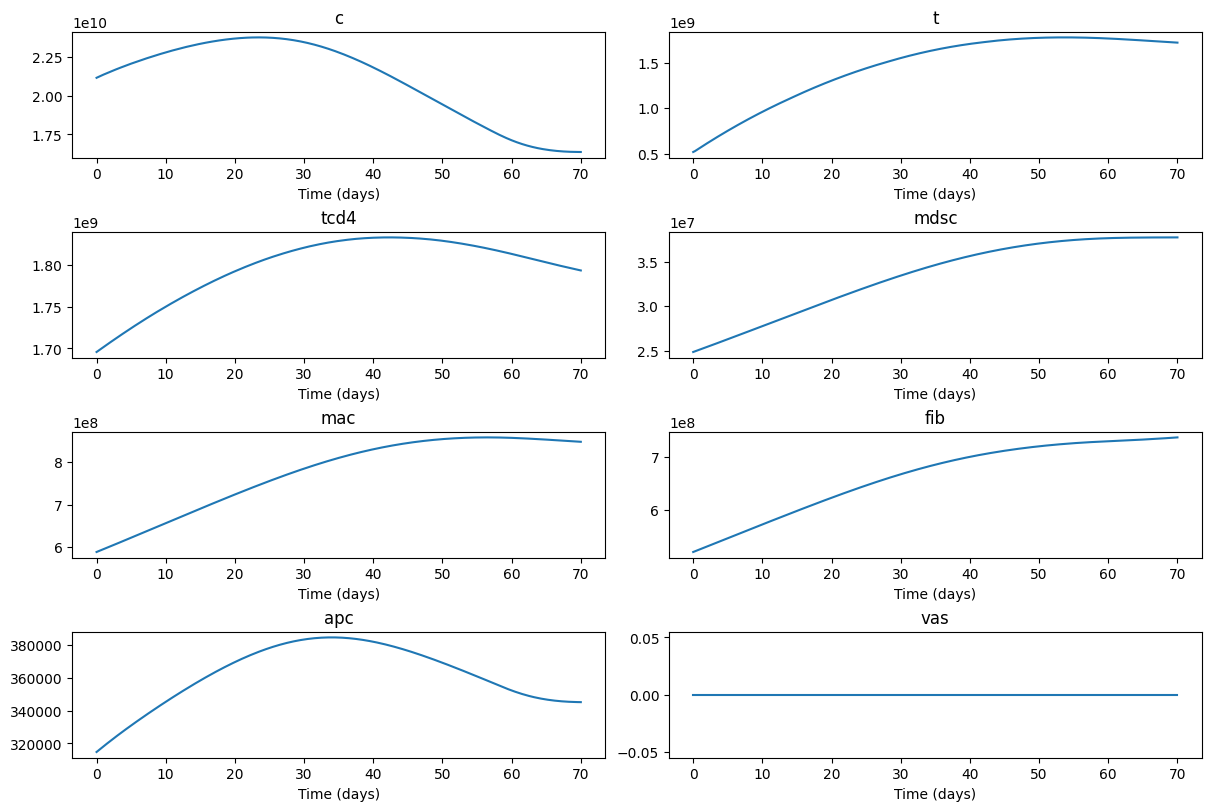

In [6]:
fig,axes = plt.subplots(4,2,figsize=(12,8),layout = 'constrained')
t = np.linspace(0,70,281)
for i,ax in enumerate(axes.reshape(-1)):
    ax.plot(t, qsp_counts[keys[i]], label = keys[i])
    ax.set_title(keys[i])
    ax.set_xlabel('Time (days)')

In [8]:
keys = ['IFNg','IL_2','CCL2','ArgI','NO','TGFB','IL10','IL12','VEGFA','O2']
mol_counts = {}
for i in range(len(keys)):
    mol_counts[keys[i]] = np.zeros(281)

for i in range(281):
    temp = pd.read_csv(path + 'snapShots/grid_core_' + str(i) + '.csv',header=0)
    for j in range(len(keys)):
        vals = temp[keys[j]].to_numpy()
        mol_counts[keys[j]][i] = np.mean(vals)

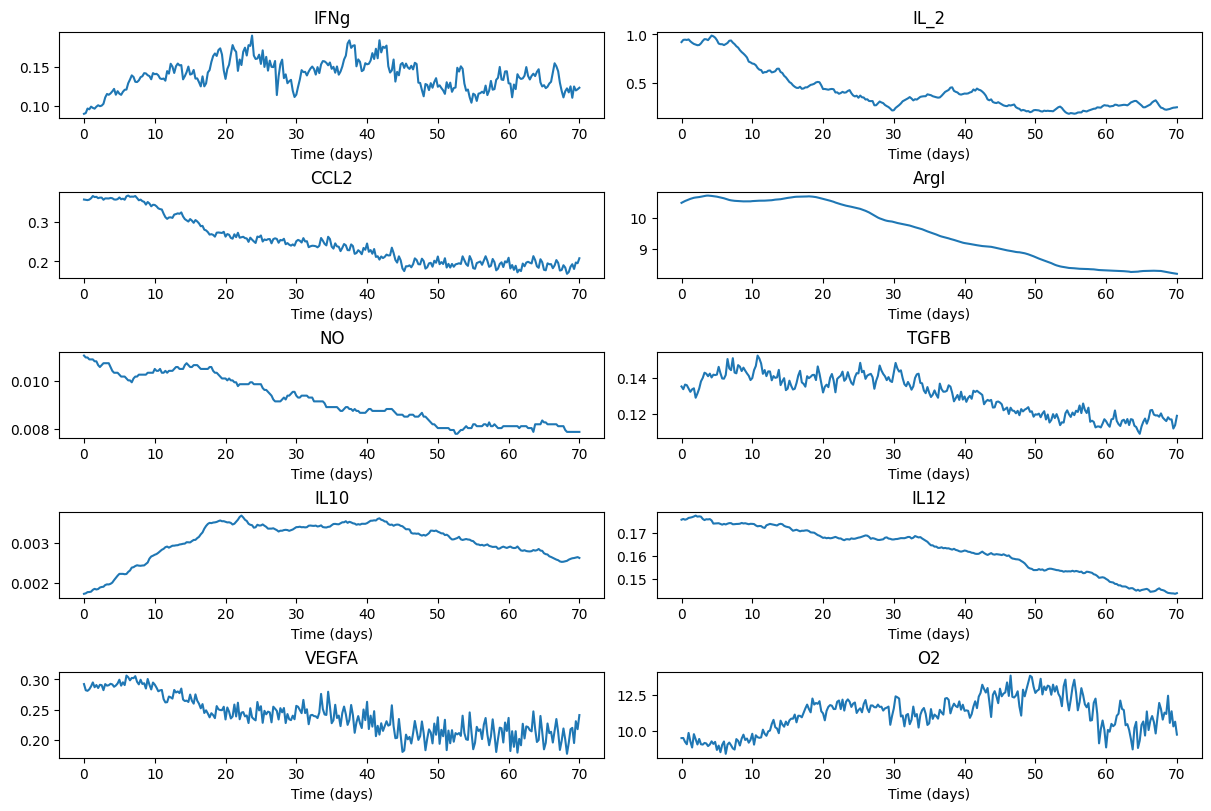

In [9]:
fig,axes = plt.subplots(5,2,figsize=(12,8),layout = 'constrained')
t = np.linspace(0,70,281)
for i,ax in enumerate(axes.reshape(-1)):
    ax.plot(t, mol_counts[keys[i]], label = keys[i])
    ax.set_title(keys[i])
    ax.set_xlabel('Time (days)')